# 03 — Modelling and Explainability

## Fetal Health Classification from Cardiotocography Signals Using Machine Learning

### Student
Gnaneshwar Katravath

### Responsibilities

- Baseline Model Development
- Ensemble Model Development
- Model Evaluation
- SHAP Explainability

### Purpose

This notebook develops and evaluates machine learning models using the processed dataset produced in the preprocessing stage.

Models:

- Logistic Regression
- Decision Tree
- Support Vector Machine
- Random Forest
- XGBoost
- LightGBM
- CatBoost
- Voting Classifier
- Stacking Classifier

The notebook also includes SHAP-based explainability analysis.

In [48]:
# =====================================================
# Library Imports
# =====================================================

import pandas as pd
import numpy as np

from pathlib import Path

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [49]:
# =====================================================
# Load Preprocessed Data
# =====================================================

DATA_DIR = Path("../data/processed")

X_train = pd.read_csv(
    DATA_DIR / "X_train_resampled.csv"
)

X_test = pd.read_csv(
    DATA_DIR / "X_test_scaled.csv"
)

y_train = pd.read_csv(
    DATA_DIR / "y_train_resampled.csv"
).squeeze()

y_test = pd.read_csv(
    DATA_DIR / "y_test.csv"
).squeeze()

print("Data Loaded Successfully")

print("\nTraining Shape:")
print(X_train.shape)

print("\nTesting Shape:")
print(X_test.shape)

Data Loaded Successfully

Training Shape:
(3948, 21)

Testing Shape:
(423, 21)


# Baseline Model Development

This section develops baseline machine learning models that will serve as reference points for later ensemble methods.

Models:

1. Logistic Regression
2. Decision Tree
3. Support Vector Machine

The models are evaluated using:

- Accuracy
- Precision
- Recall
- F1 Score

These results will later be compared against ensemble learning approaches.

In [50]:
# =====================================================
# Logistic Regression
# =====================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

lr_model.fit(
    X_train,
    y_train
)

lr_pred = lr_model.predict(
    X_test
)

print(
    "Logistic Regression Training Complete"
)

Logistic Regression Training Complete


In [51]:
# =====================================================
# Logistic Regression Evaluation
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lr_accuracy = accuracy_score(
    y_test,
    lr_pred
)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        lr_accuracy,
        lr_precision,
        lr_recall,
        lr_f1
    ]

})

lr_results

,Metric,Value
0,Accuracy,0.881797
1,Precision,0.908000
2,Recall,0.881797
3,F1 Score,0.889944


# Decision Tree Model

Decision Trees are used as a baseline non-linear model.

Unlike Logistic Regression, Decision Trees can capture non-linear relationships and feature interactions without requiring explicit feature transformations.

The model will be evaluated using the same metrics for fair comparison.

In [52]:
# =====================================================
# Decision Tree Classifier
# =====================================================

from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

dt_model.fit(
    X_train,
    y_train
)

dt_pred = dt_model.predict(
    X_test
)

print(
    "Decision Tree Training Complete"
)

Decision Tree Training Complete


In [53]:
# =====================================================
# Decision Tree Evaluation
# =====================================================

dt_accuracy = accuracy_score(
    y_test,
    dt_pred
)

dt_precision = precision_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_recall = recall_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_f1 = f1_score(
    y_test,
    dt_pred,
    average="weighted"
)

dt_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        dt_accuracy,
        dt_precision,
        dt_recall,
        dt_f1
    ]

})

dt_results

,Metric,Value
0,Accuracy,0.931442
1,Precision,0.933945
2,Recall,0.931442
3,F1 Score,0.932468


In [54]:
# =====================================================
# Baseline Model Comparison
# =====================================================

baseline_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1
    ]
})

baseline_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944
1,Decision Tree,0.931442,0.933945,0.931442,0.932468


# Support Vector Machine (SVM)

Support Vector Machines are powerful classifiers that attempt to find an optimal decision boundary between classes.

Because the CTG dataset has already been scaled during preprocessing, SVM can be evaluated fairly against Logistic Regression and Decision Tree models.

The model performance will be compared using Accuracy, Precision, Recall, and F1 Score.

In [55]:
# =====================================================
# Support Vector Machine
# =====================================================

from sklearn.svm import SVC

svm_model = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42
)

svm_model.fit(
    X_train,
    y_train
)

svm_pred = svm_model.predict(
    X_test
)

print(
    "SVM Training Complete"
)

SVM Training Complete


In [56]:
# =====================================================
# SVM Evaluation
# =====================================================

svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_precision = precision_score(
    y_test,
    svm_pred,
    average="weighted"
)

svm_recall = recall_score(
    y_test,
    svm_pred,
    average="weighted"
)

svm_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted"
)

svm_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        svm_accuracy,
        svm_precision,
        svm_recall,
        svm_f1
    ]

})

svm_results

,Metric,Value
0,Accuracy,0.900709
1,Precision,0.920735
2,Recall,0.900709
3,F1 Score,0.906881


In [57]:
# =====================================================
# Final Baseline Model Comparison
# =====================================================

baseline_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "SVM"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        svm_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        svm_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        svm_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        svm_f1
    ]
})

baseline_results.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score
1,Decision Tree,0.931442,0.933945,0.931442,0.932468
2,SVM,0.900709,0.920735,0.900709,0.906881
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944


# Ensemble Model Development

Ensemble learning combines multiple decision rules to improve predictive performance and generalisation.

The first ensemble model evaluated is Random Forest, which reduces overfitting by aggregating predictions from multiple decision trees.

Performance will be compared against the previously developed baseline models.

In [58]:
# =====================================================
# Random Forest Classifier
# =====================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train,
    y_train
)

rf_pred = rf_model.predict(
    X_test
)

print(
    "Random Forest Training Complete"
)

Random Forest Training Complete


In [59]:
# =====================================================
# Random Forest Evaluation
# =====================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        rf_accuracy,
        rf_precision,
        rf_recall,
        rf_f1
    ]

})

rf_results

,Metric,Value
0,Accuracy,0.943262
1,Precision,0.942719
2,Recall,0.943262
3,F1 Score,0.942784


In [60]:
# =====================================================
# Model Comparison (Baseline + Random Forest)
# =====================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        svm_accuracy,
        rf_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        svm_precision,
        rf_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        svm_recall,
        rf_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        svm_f1,
        rf_f1
    ]
})

comparison_results = comparison_results.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score
3,Random Forest,0.943262,0.942719,0.943262,0.942784
1,Decision Tree,0.931442,0.933945,0.931442,0.932468
2,SVM,0.900709,0.920735,0.900709,0.906881
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944


In [61]:
# =====================================================
# Random Forest Feature Importance
# =====================================================

feature_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
    rf_model.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

feature_importance.head(10)

,Feature,Importance
7,ASTV,0.134394
9,ALTV,0.134121
17,Mean,0.105766
1,AC,0.083817
8,MSTV,0.077263
18,Median,0.077068
6,DP,0.067415
16,Mode,0.052760
10,MLTV,0.046887
0,LB,0.040399


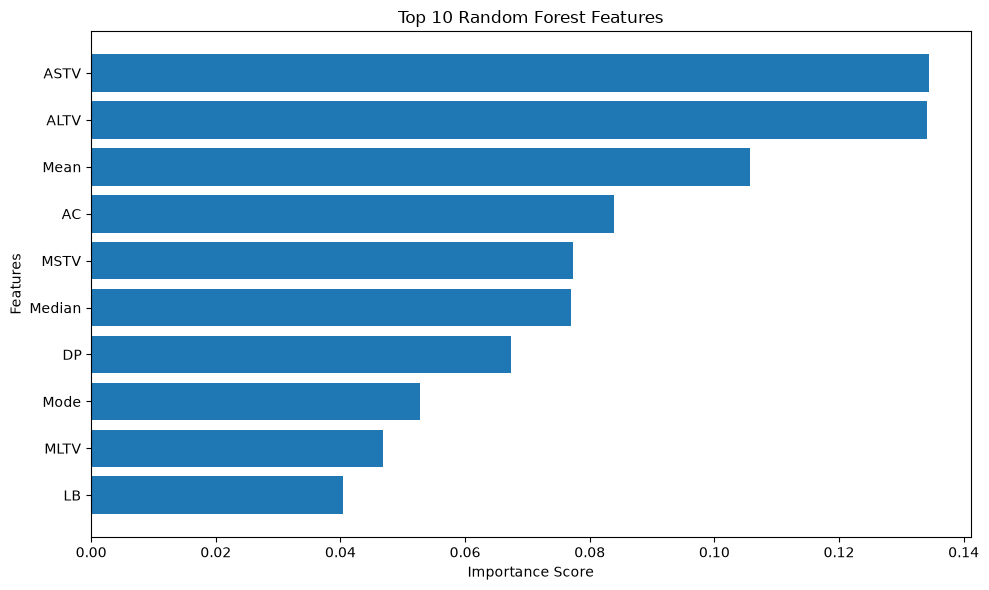

Figure saved successfully:
D:\fetal-health-classification-group16\outputs\random_forest_feature_importance.png


In [62]:
# =====================================================
# Feature Importance Visualization
# =====================================================

from pathlib import Path
import matplotlib.pyplot as plt

# Create output folder if it doesn't exist
OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top_features = (
    feature_importance
    .head(10)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 Random Forest Features"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.tight_layout()

save_path = (
    OUTPUT_DIR /
    "random_forest_feature_importance.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved successfully:\n{save_path.resolve()}"
)

In [63]:
from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

baseline_results.to_csv(
    OUTPUT_DIR /
    "baseline_model_results.csv",
    index=False
)

print(
    "baseline_model_results.csv saved successfully"
)

baseline_model_results.csv saved successfully


# XGBoost Classifier

Extreme Gradient Boosting (XGBoost) is a boosting-based ensemble learning algorithm that sequentially improves weak learners by focusing on previously misclassified observations.

XGBoost is widely used in structured healthcare datasets because of its strong predictive performance and ability to model complex feature interactions.

The model will be evaluated using the same metrics as previous classifiers.

In [64]:
# =====================================================
# XGBoost Classifier
# =====================================================

from xgboost import XGBClassifier

# XGBoost requires classes starting from 0
y_train_xgb = y_train - 1
y_test_xgb = y_test - 1

xgb_model = XGBClassifier(

    objective="multi:softmax",

    num_class=3,

    n_estimators=200,

    max_depth=6,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="mlogloss"
)

xgb_model.fit(
    X_train,
    y_train_xgb
)

xgb_pred = xgb_model.predict(
    X_test
)

print(
    "XGBoost Training Complete"
)

XGBoost Training Complete


In [65]:
# =====================================================
# XGBoost Evaluation
# =====================================================

xgb_accuracy = accuracy_score(
    y_test_xgb,
    xgb_pred
)

xgb_precision = precision_score(
    y_test_xgb,
    xgb_pred,
    average="weighted"
)

xgb_recall = recall_score(
    y_test_xgb,
    xgb_pred,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test_xgb,
    xgb_pred,
    average="weighted"
)

xgb_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        xgb_accuracy,
        xgb_precision,
        xgb_recall,
        xgb_f1
    ]

})

xgb_results

,Metric,Value
0,Accuracy,0.966903
1,Precision,0.966328
2,Recall,0.966903
3,F1 Score,0.965847


In [66]:
# =====================================================
# Update Model Leaderboard
# =====================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "XGBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        svm_precision,
        rf_precision,
        xgb_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        svm_recall,
        rf_recall,
        xgb_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        svm_f1,
        rf_f1,
        xgb_f1
    ]
})

comparison_results = comparison_results.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score
4,XGBoost,0.966903,0.966328,0.966903,0.965847
3,Random Forest,0.943262,0.942719,0.943262,0.942784
1,Decision Tree,0.931442,0.933945,0.931442,0.932468
2,SVM,0.900709,0.920735,0.900709,0.906881
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944


In [67]:
# =====================================================
# XGBoost Feature Importance
# =====================================================

xgb_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
    xgb_model.feature_importances_

})

xgb_importance = (
    xgb_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

xgb_importance.head(10)

,Feature,Importance
1,AC,0.143409
17,Mean,0.130785
9,ALTV,0.124055
6,DP,0.096548
18,Median,0.080191
7,ASTV,0.078668
5,DS,0.071961
8,MSTV,0.047706
0,LB,0.030542
16,Mode,0.027857


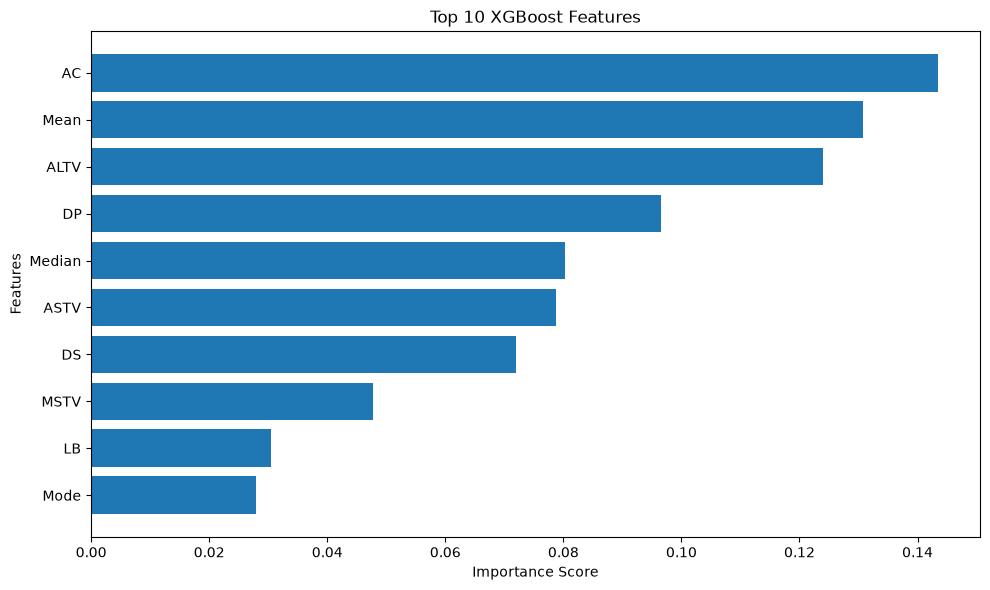

Figure saved successfully:
D:\fetal-health-classification-group16\outputs\xgboost_feature_importance.png


In [68]:
# =====================================================
# XGBoost Feature Importance Plot
# =====================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top_features = (
    xgb_importance
    .head(10)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 XGBoost Features"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.tight_layout()

save_path = (
    OUTPUT_DIR /
    "xgboost_feature_importance.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved successfully:\n{save_path.resolve()}"
)

# LightGBM Classifier

LightGBM is a gradient boosting framework developed by Microsoft. It is designed to be faster and more memory efficient than traditional boosting algorithms while maintaining high predictive performance.

For structured tabular datasets such as CTG measurements, LightGBM is frequently reported as one of the strongest machine learning models.

In [69]:
# =====================================================
# LightGBM Classifier
# =====================================================

from lightgbm import LGBMClassifier

# LightGBM requires class labels starting from 0
y_train_lgbm = y_train - 1
y_test_lgbm = y_test - 1

lgbm_model = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    verbosity=-1
)

lgbm_model.fit(
    X_train,
    y_train_lgbm
)

lgbm_pred = lgbm_model.predict(
    X_test
)

print("LightGBM Training Complete")

LightGBM Training Complete


In [70]:
# =====================================================
# LightGBM Evaluation
# =====================================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

lgbm_accuracy = accuracy_score(
    y_test_lgbm,
    lgbm_pred
)

lgbm_precision = precision_score(
    y_test_lgbm,
    lgbm_pred,
    average="weighted"
)

lgbm_recall = recall_score(
    y_test_lgbm,
    lgbm_pred,
    average="weighted"
)

lgbm_f1 = f1_score(
    y_test_lgbm,
    lgbm_pred,
    average="weighted"
)

lgbm_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        lgbm_accuracy,
        lgbm_precision,
        lgbm_recall,
        lgbm_f1
    ]
})

lgbm_results

,Metric,Value
0,Accuracy,0.966903
1,Precision,0.966226
2,Recall,0.966903
3,F1 Score,0.966148


In [71]:
# =====================================================
# LightGBM Feature Importance
# =====================================================

lgbm_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
    lgbm_model.feature_importances_

})

lgbm_importance = (
    lgbm_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

lgbm_importance.head(10)

,Feature,Importance
7,ASTV,2138
9,ALTV,1804
3,UC,1143
17,Mean,1139
0,LB,951
8,MSTV,950
16,Mode,937
10,MLTV,935
2,FM,784
14,Nmax,781


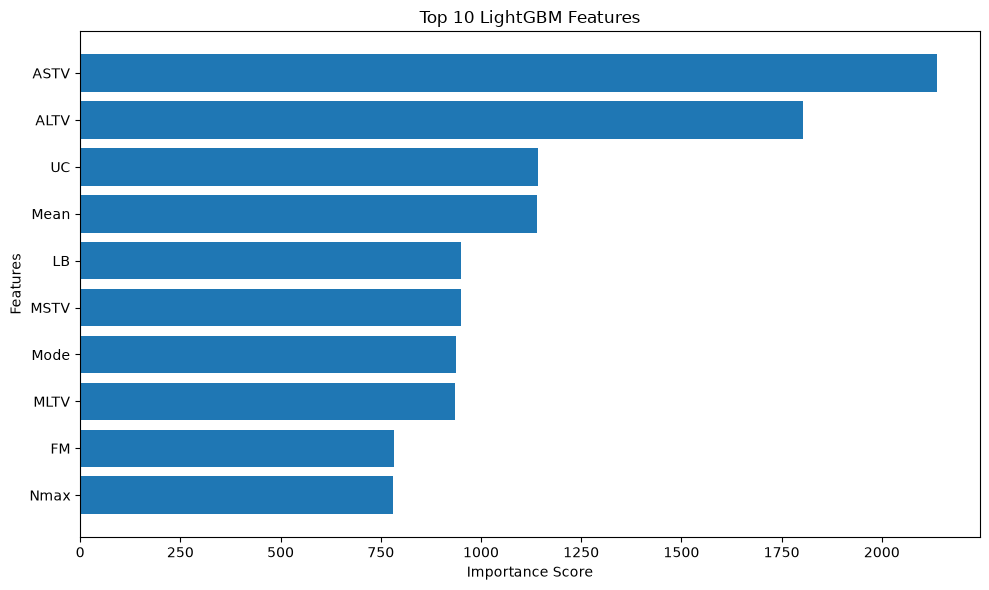

Figure saved successfully:
D:\fetal-health-classification-group16\outputs\lightgbm_feature_importance.png


In [72]:
# =====================================================
# LightGBM Feature Importance Plot
# =====================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top_features = (
    lgbm_importance
    .head(10)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 LightGBM Features"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.tight_layout()

save_path = (
    OUTPUT_DIR /
    "lightgbm_feature_importance.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved successfully:\n{save_path.resolve()}"
)

In [73]:
# =====================================================
# Update Leaderboard
# =====================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        svm_precision,
        rf_precision,
        xgb_precision,
        lgbm_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        svm_recall,
        rf_recall,
        xgb_recall,
        lgbm_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        svm_f1,
        rf_f1,
        xgb_f1,
        lgbm_f1
    ]
})

comparison_results = comparison_results.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score
5,LightGBM,0.966903,0.966226,0.966903,0.966148
4,XGBoost,0.966903,0.966328,0.966903,0.965847
3,Random Forest,0.943262,0.942719,0.943262,0.942784
1,Decision Tree,0.931442,0.933945,0.931442,0.932468
2,SVM,0.900709,0.920735,0.900709,0.906881
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944


# CatBoost Classifier

CatBoost is a gradient boosting algorithm developed by Yandex. It is designed to reduce prediction shift and overfitting while maintaining strong performance on structured datasets.

CatBoost often performs competitively with XGBoost and LightGBM and is therefore included in the ensemble model comparison.

In [74]:
# =====================================================
# CatBoost Classifier
# =====================================================

from catboost import CatBoostClassifier

y_train_cat = y_train - 1
y_test_cat = y_test - 1

cat_model = CatBoostClassifier(

    iterations=200,

    depth=6,

    learning_rate=0.05,

    loss_function="MultiClass",

    random_state=42,

    verbose=False
)

cat_model.fit(
    X_train,
    y_train_cat
)

cat_pred = cat_model.predict(
    X_test
)

cat_pred = cat_pred.astype(int).flatten()

print(
    "CatBoost Training Complete"
)

CatBoost Training Complete


In [75]:
# =====================================================
# CatBoost Evaluation
# =====================================================

cat_accuracy = accuracy_score(
    y_test_cat,
    cat_pred
)

cat_precision = precision_score(
    y_test_cat,
    cat_pred,
    average="weighted"
)

cat_recall = recall_score(
    y_test_cat,
    cat_pred,
    average="weighted"
)

cat_f1 = f1_score(
    y_test_cat,
    cat_pred,
    average="weighted"
)

cat_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        cat_accuracy,
        cat_precision,
        cat_recall,
        cat_f1
    ]
})

cat_results

,Metric,Value
0,Accuracy,0.929078
1,Precision,0.930912
2,Recall,0.929078
3,F1 Score,0.929679


In [76]:
# =====================================================
# CatBoost Feature Importance
# =====================================================

cat_importance = pd.DataFrame({

    "Feature": X_train.columns,

    "Importance":
    cat_model.feature_importances_

})

cat_importance = (
    cat_importance
    .sort_values(
        by="Importance",
        ascending=False
    )
)

cat_importance.head(10)

,Feature,Importance
9,ALTV,18.839979
7,ASTV,15.484813
17,Mean,11.332078
1,AC,8.067335
6,DP,7.142301
8,MSTV,6.506101
18,Median,6.257974
3,UC,4.574253
16,Mode,3.553982
10,MLTV,2.961143


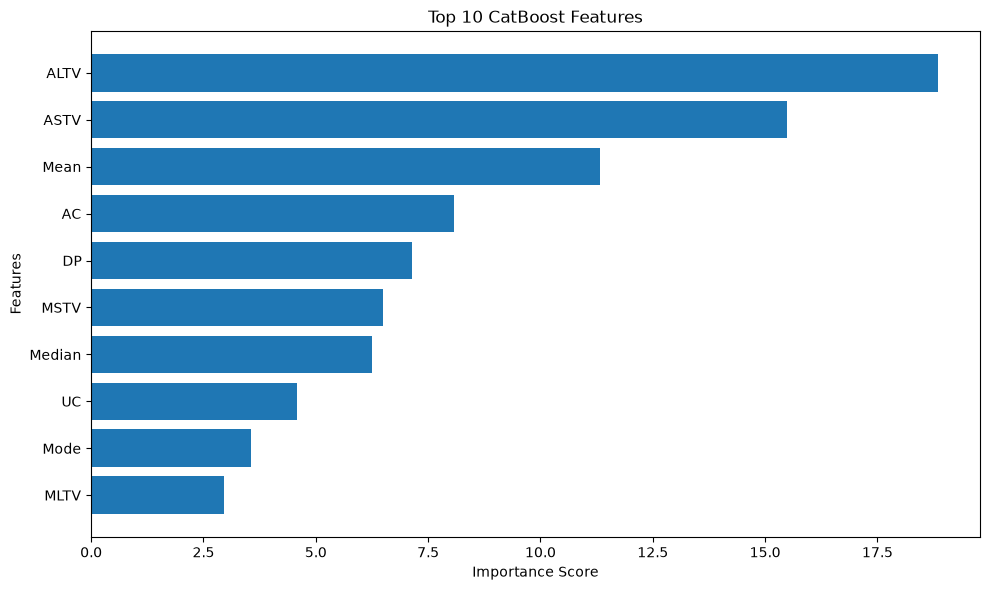

Figure saved successfully:
D:\fetal-health-classification-group16\outputs\catboost_feature_importance.png


In [77]:
# =====================================================
# CatBoost Feature Importance Plot
# =====================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top_features = (
    cat_importance
    .head(10)
    .sort_values(
        by="Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title(
    "Top 10 CatBoost Features"
)

plt.xlabel(
    "Importance Score"
)

plt.ylabel(
    "Features"
)

plt.tight_layout()

save_path = (
    OUTPUT_DIR /
    "catboost_feature_importance.png"
)

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    f"Figure saved successfully:\n{save_path.resolve()}"
)

In [78]:
# =====================================================
# Update Model Leaderboard
# =====================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        svm_precision,
        rf_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        svm_recall,
        rf_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        svm_f1,
        rf_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1
    ]
})

comparison_results = comparison_results.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score
5,LightGBM,0.966903,0.966226,0.966903,0.966148
4,XGBoost,0.966903,0.966328,0.966903,0.965847
3,Random Forest,0.943262,0.942719,0.943262,0.942784
1,Decision Tree,0.931442,0.933945,0.931442,0.932468
6,CatBoost,0.929078,0.930912,0.929078,0.929679
2,SVM,0.900709,0.920735,0.900709,0.906881
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944


# Voting Classifier

Voting is an ensemble learning technique that combines predictions from multiple machine learning models.

In this project, the Voting Classifier combines:

- Random Forest
- XGBoost
- LightGBM

The final prediction is determined through soft voting, where class probabilities from individual models are averaged before selecting the final class.

In [79]:
# =====================================================
# Voting Classifier
# =====================================================

from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(

    estimators=[

        ("rf", rf_model),

        ("xgb", xgb_model),

        ("lgbm", lgbm_model)

    ],

    voting="soft"
)

voting_model.fit(
    X_train,
    y_train_xgb
)

voting_pred = voting_model.predict(
    X_test
)

print(
    "Voting Classifier Training Complete"
)

Voting Classifier Training Complete


In [80]:
# =====================================================
# Voting Classifier Evaluation
# =====================================================

voting_accuracy = accuracy_score(
    y_test_xgb,
    voting_pred
)

voting_precision = precision_score(
    y_test_xgb,
    voting_pred,
    average="weighted"
)

voting_recall = recall_score(
    y_test_xgb,
    voting_pred,
    average="weighted"
)

voting_f1 = f1_score(
    y_test_xgb,
    voting_pred,
    average="weighted"
)

voting_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        voting_accuracy,
        voting_precision,
        voting_recall,
        voting_f1
    ]

})

voting_results

,Metric,Value
0,Accuracy,0.964539
1,Precision,0.963927
2,Recall,0.964539
3,F1 Score,0.963267


In [81]:
# =====================================================
# Update Leaderboard With Voting Classifier
# =====================================================

comparison_results = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "SVM",
        "Random Forest",
        "XGBoost",
        "LightGBM",
        "CatBoost",
        "Voting Classifier"
    ],

    "Accuracy":[
        lr_accuracy,
        dt_accuracy,
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy,
        lgbm_accuracy,
        cat_accuracy,
        voting_accuracy
    ],

    "Precision":[
        lr_precision,
        dt_precision,
        svm_precision,
        rf_precision,
        xgb_precision,
        lgbm_precision,
        cat_precision,
        voting_precision
    ],

    "Recall":[
        lr_recall,
        dt_recall,
        svm_recall,
        rf_recall,
        xgb_recall,
        lgbm_recall,
        cat_recall,
        voting_recall
    ],

    "F1 Score":[
        lr_f1,
        dt_f1,
        svm_f1,
        rf_f1,
        xgb_f1,
        lgbm_f1,
        cat_f1,
        voting_f1
    ]
})

comparison_results = comparison_results.sort_values(
    by="F1 Score",
    ascending=False
)

comparison_results

,Model,Accuracy,Precision,Recall,F1 Score
5,LightGBM,0.966903,0.966226,0.966903,0.966148
4,XGBoost,0.966903,0.966328,0.966903,0.965847
7,Voting Classifier,0.964539,0.963927,0.964539,0.963267
3,Random Forest,0.943262,0.942719,0.943262,0.942784
1,Decision Tree,0.931442,0.933945,0.931442,0.932468
6,CatBoost,0.929078,0.930912,0.929078,0.929679
2,SVM,0.900709,0.920735,0.900709,0.906881
0,Logistic Regression,0.881797,0.908000,0.881797,0.889944


In [82]:
# =====================================================
# Save Model Comparison Results
# =====================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

comparison_results.to_csv(
    OUTPUT_DIR /
    "model_comparison_results.csv",
    index=False
)

print(
    "Model comparison results saved successfully"
)

Model comparison results saved successfully


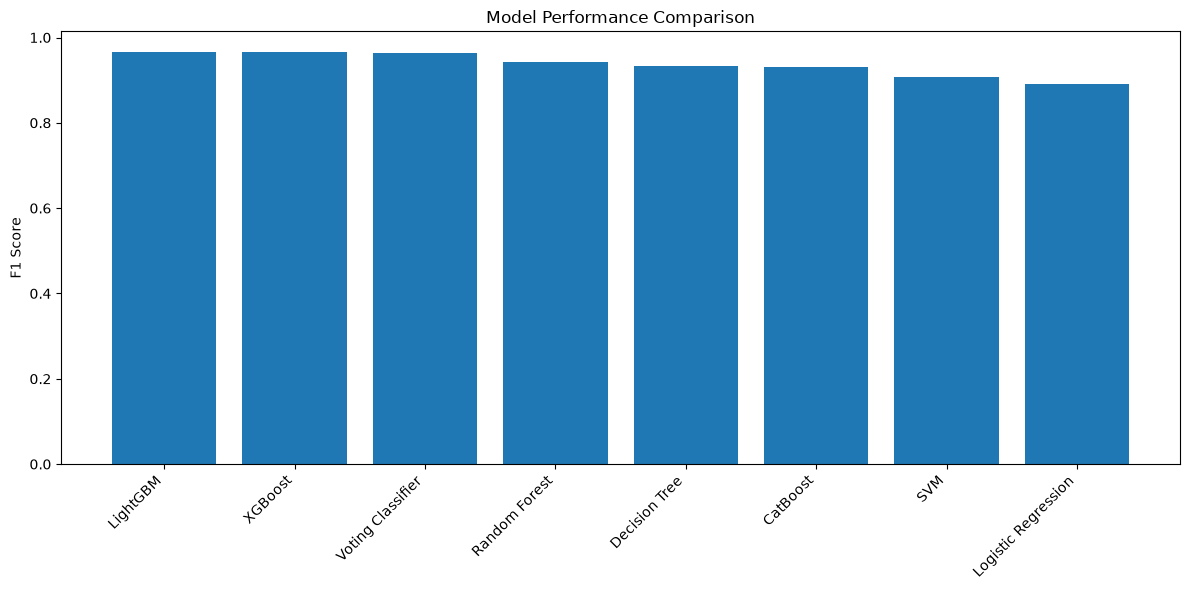

Chart saved successfully


In [83]:
# =====================================================
# Visual Comparison Of Models
# =====================================================

plt.figure(
    figsize=(12,6)
)

plt.bar(
    comparison_results["Model"],
    comparison_results["F1 Score"]
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.ylabel(
    "F1 Score"
)

plt.title(
    "Model Performance Comparison"
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "model_comparison_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Chart saved successfully"
)

# Stacking Classifier

Stacking is an ensemble learning technique where predictions from multiple base models are used as inputs to a final meta-model.

In this implementation:

Base Models:
- Random Forest
- XGBoost
- LightGBM

Meta Model:
- Logistic Regression

The objective is to determine whether combining multiple strong learners improves predictive performance over individual models.

In [84]:
# =====================================================
# Stacking Classifier
# =====================================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_model = StackingClassifier(

    estimators=[

        ("rf", rf_model),

        ("xgb", xgb_model),

        ("lgbm", lgbm_model)

    ],

    final_estimator=LogisticRegression(
        max_iter=1000
    ),

    cv=5,

    n_jobs=-1
)

stacking_model.fit(
    X_train,
    y_train_xgb
)

stacking_pred = stacking_model.predict(
    X_test
)

print(
    "Stacking Classifier Training Complete"
)

Stacking Classifier Training Complete


In [85]:
# =====================================================
# Stacking Evaluation
# =====================================================

stacking_accuracy = accuracy_score(
    y_test_xgb,
    stacking_pred
)

stacking_precision = precision_score(
    y_test_xgb,
    stacking_pred,
    average="weighted"
)

stacking_recall = recall_score(
    y_test_xgb,
    stacking_pred,
    average="weighted"
)

stacking_f1 = f1_score(
    y_test_xgb,
    stacking_pred,
    average="weighted"
)

stacking_results = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Value":[
        stacking_accuracy,
        stacking_precision,
        stacking_recall,
        stacking_f1
    ]
})

stacking_results

,Metric,Value
0,Accuracy,0.964539
1,Precision,0.963927
2,Recall,0.964539
3,F1 Score,0.963267


 Model Explainability Using SHAP

SHAP (SHapley Additive exPlanations) was used to interpret model predictions and identify the most influential clinical features.

Feature importance rankings generated by SHAP provide transparency and help explain how different cardiotocography measurements contribute to fetal health classification decisions.

In [86]:
# =====================================================
# SHAP Explainability Setup
# =====================================================

import shap

print(
    "SHAP Version:",
    shap.__version__
)

# Best model identified so far
best_model = lgbm_model

explainer = shap.TreeExplainer(
    best_model
)

shap_values = explainer.shap_values(
    X_test
)

print(
    "SHAP values generated successfully"
)

SHAP Version: 0.52.0
SHAP values generated successfully


<Figure size 640x480 with 0 Axes>

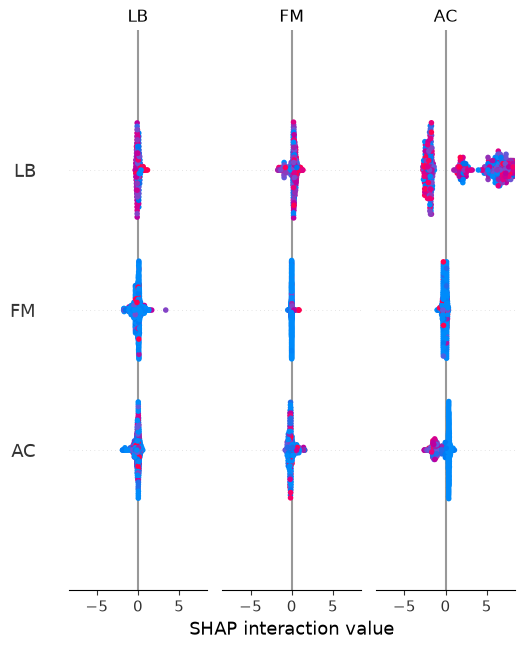

SHAP summary plot saved successfully


In [87]:
# =====================================================
# SHAP Summary Plot
# =====================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

plt.figure()

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR /
    "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "SHAP summary plot saved successfully"
)

In [88]:
# =====================================================
# SHAP Feature Importance Table
# =====================================================

import numpy as np

print("SHAP Values Shape:")
print(np.array(shap_values).shape)

# Handle multiclass SHAP output
if len(np.array(shap_values).shape) == 3:

    mean_shap = np.mean(
        np.abs(shap_values),
        axis=(0, 2)
    )

elif isinstance(shap_values, list):

    mean_shap = np.mean(
        [
            np.abs(class_values).mean(axis=0)
            for class_values in shap_values
        ],
        axis=0
    )

else:

    mean_shap = np.abs(
        shap_values
    ).mean(axis=0)

shap_importance = pd.DataFrame({

    "Feature": X_test.columns,

    "Mean_SHAP_Importance": mean_shap

})

shap_importance = shap_importance.sort_values(

    by="Mean_SHAP_Importance",

    ascending=False

)

print("\nTop SHAP Features")
print("=" * 50)

shap_importance.head(15)

SHAP Values Shape:
(423, 21, 3)

Top SHAP Features


,Feature,Mean_SHAP_Importance
1,AC,1.016629
7,ASTV,0.862338
9,ALTV,0.805763
17,Mean,0.540927
6,DP,0.525827
16,Mode,0.434729
18,Median,0.387482
3,UC,0.252090
8,MSTV,0.208508
19,Variance,0.201112


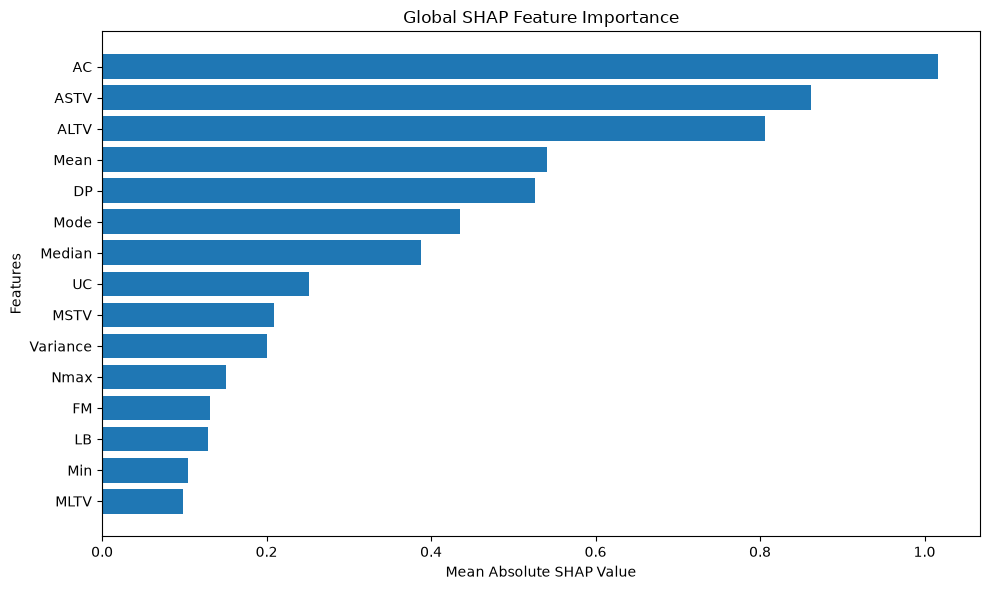

Saved: ..\outputs\shap_feature_importance.png


In [89]:
# =====================================================
# SHAP Global Feature Importance Plot
# =====================================================

from pathlib import Path

OUTPUT_DIR = Path("../outputs")

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

top_shap = (
    shap_importance
    .head(15)
    .sort_values(
        by="Mean_SHAP_Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10,6)
)

plt.barh(
    top_shap["Feature"],
    top_shap["Mean_SHAP_Importance"]
)

plt.title(
    "Global SHAP Feature Importance"
)

plt.xlabel(
    "Mean Absolute SHAP Value"
)

plt.ylabel(
    "Features"
)

plt.tight_layout()

save_path = OUTPUT_DIR / "shap_feature_importance.png"

plt.savefig(
    save_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {save_path}")

In [90]:
# =====================================================
# Final Model Leaderboard
# =====================================================

final_leaderboard = comparison_results.copy()

if "Stacking" not in final_leaderboard["Model"].values:

    stacking_row = pd.DataFrame({

        "Model":["Stacking"],

        "Accuracy":[stacking_accuracy],

        "Precision":[stacking_precision],

        "Recall":[stacking_recall],

        "F1 Score":[stacking_f1]

    })

    final_leaderboard = pd.concat(
        [final_leaderboard, stacking_row],
        ignore_index=True
    )

final_leaderboard = final_leaderboard.sort_values(

    by="F1 Score",

    ascending=False

)

final_leaderboard

,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM,0.966903,0.966226,0.966903,0.966148
1,XGBoost,0.966903,0.966328,0.966903,0.965847
2,Voting Classifier,0.964539,0.963927,0.964539,0.963267
8,Stacking,0.964539,0.963927,0.964539,0.963267
3,Random Forest,0.943262,0.942719,0.943262,0.942784
4,Decision Tree,0.931442,0.933945,0.931442,0.932468
5,CatBoost,0.929078,0.930912,0.929078,0.929679
6,SVM,0.900709,0.920735,0.900709,0.906881
7,Logistic Regression,0.881797,0.908000,0.881797,0.889944


In [91]:
from sklearn.metrics import (
    matthews_corrcoef,
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix
)

import joblib
from pathlib import Path

In [92]:
print("="*70)
print("DATASET SUMMARY")
print("="*70)

print(f"Training Samples : {X_train.shape[0]}")
print(f"Testing Samples  : {X_test.shape[0]}")
print(f"Features         : {X_train.shape[1]}")

print("\nTraining Class Distribution")

print(y_train.value_counts())

print("\nTesting Class Distribution")

print(y_test.value_counts())

DATASET SUMMARY
Training Samples : 3948
Testing Samples  : 423
Features         : 21

Training Class Distribution
NSP
1.0    1316
2.0    1316
3.0    1316
Name: count, dtype: int64

Testing Class Distribution
NSP
1.0    330
2.0     58
3.0     35
Name: count, dtype: int64


# XGBoost Hyperparameter Tuning

### Purpose

The default XGBoost model provides excellent predictive performance. However, its hyperparameters may not be optimal for this dataset.

To improve generalisation and maximise predictive performance, Randomized Search Cross Validation is performed. This approach evaluates multiple hyperparameter combinations using stratified cross-validation while reducing computational cost compared with exhaustive grid search.

The tuned model will later be compared with the default implementation using twelve evaluation metrics.

In [93]:
# ==========================================================
# ENCODE TARGET FOR XGBOOST
# ==========================================================

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)

y_test_xgb = label_encoder.transform(y_test)

print("Original Classes :", sorted(y_train.unique()))
print("Encoded Classes  :", sorted(np.unique(y_train_xgb)))

Original Classes : [np.float64(1.0), np.float64(2.0), np.float64(3.0)]
Encoded Classes  : [np.int64(0), np.int64(1), np.int64(2)]


In [94]:
# ==========================================================
# XGBOOST HYPERPARAMETER TUNING
# ==========================================================

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold

from xgboost import XGBClassifier

import numpy as np

print("="*70)
print("XGBOOST HYPERPARAMETER TUNING")
print("="*70)

param_grid = {

    "n_estimators":[100,200,300,500],

    "max_depth":[3,4,5,6,8],

    "learning_rate":[0.01,0.03,0.05,0.1],

    "subsample":[0.7,0.8,0.9,1.0],

    "colsample_bytree":[0.7,0.8,0.9,1.0],

    "gamma":[0,0.1,0.2],

    "min_child_weight":[1,3,5]

}

cv = StratifiedKFold(

    n_splits=5,

    shuffle=True,

    random_state=42

)

xgb_search = RandomizedSearchCV(

    estimator=XGBClassifier(

        objective="multi:softprob",

        num_class=3,

        eval_metric="mlogloss",

        random_state=42

    ),

    param_distributions=param_grid,

    n_iter=25,

    scoring="f1_weighted",

    cv=cv,

    verbose=1,

    random_state=42,

    n_jobs=-1

)

xgb_search.fit(
    
    X_train,
    
    y_train.astype(int) - 1

)

best_xgb = xgb_search.best_estimator_

print("\nBest Parameters\n")

print(xgb_search.best_params_)

print("\nBest CV Score")

print(round(xgb_search.best_score_,4))

XGBOOST HYPERPARAMETER TUNING
Fitting 5 folds for each of 25 candidates, totalling 125 fits

Best Parameters

{'subsample': 0.7, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0, 'colsample_bytree': 0.9}

Best CV Score
0.982
